# Auswertung des Parameter-Sweeps
Zeigt alle Abbildungen und Tabellen aus Kapitel 5 und Anhang B der Arbeit an.

Reihenfolge: zuerst `preprocessing.py`, dann `run_simulation.py` (führt am Ende auch `reason_analysis.py` aus) und danach `verkettung.py`. Wurde die Simulation mit `direct_analysis=True` gestartet, unten `direct = True` setzen.

Die Abschnitte zur Referenz-Slotreihe (10, 25, 50, 100, 225 und 600 Slots) brauchen zusätzlich die Rohdaten in `raw_sweeps`. Diese werden über `keep_raw` immer gespeichert.

In [ ]:
import ast
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

results_dir = Path("Data/ergebnisse")
# True wenn run_simulation.py mit direct_analysis=True gelaufen ist
direct = False
suffix = "_direkt" if direct else ""
trigger_file = results_dir / f"sweep_trigger_analyse{suffix}.csv"
ranking_file = results_dir / f"verkettungs_ranking{suffix}.csv"
segments_dir = results_dir / "raw_sweeps"

n_users = 2148
ref = {"Slots": 100, "Max_Domains": 10, "Max_Events": 700, "Max_Days": 7}
ref_name = f"{ref['Slots']}_{ref['Max_Domains']}_{ref['Max_Events']}_{ref['Max_Days']}"
# Slotanzahlen, für die keep_raw in run_simulation.py existiert
slot_list = [10, 25, 50, 100, 225, 600]

# Abschlussgrund in der CSV für die beschriftungen in den diagrammen.
reasons = {
    "Days": "Rotation: Zeit",
    "Events": "Rotation: Events",
    "Domains": "Rotation: Domains",
    "expired": "Am Datenende abgelaufen",
    "end_of_stream": "Am Datenende offen",
}
colors = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]
incl_color, excl_color = colors[0], colors[1]
plt.rcParams.update({"font.size": 12, "axes.labelsize": 12, "xtick.labelsize": 11, "ytick.labelsize": 11, "legend.fontsize": 11, "axes.titlesize": 12})

# Slotwerte für balkendiagramm
bar_slots = [10, 15, 25, 35, 50, 75, 100, 150, 225, 400, 600]

def style(ax):
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", color="#e5e5e5", linewidth=0.6)
    ax.set_axisbelow(True)

def slot_axis(ax):
    # Log-Skala mit lesbaren Ticks für die Slotreihe
    ax.set_xscale("log")
    ax.set_xticks([10, 25, 50, 100, 200, 400, 600])
    ax.set_xticklabels(["10", "25", "50", "100", "200", "400", "600"])

def raw_name(slots):
    # Dateiname der rohdaten
    return f"{slots}_{ref['Max_Domains']}_{ref['Max_Events']}_{ref['Max_Days']}"

## Daten laden

In [23]:
trigger = pd.read_csv(trigger_file)

# Trigger distribution als Dict-String speichern
dist = trigger["Trigger_Distribution"].apply(ast.literal_eval).apply(pd.Series)
dist = dist.reindex(columns=reasons.keys()).fillna(0) * 100
dist.columns = reasons.values()
trigger = pd.concat([trigger, dist], axis=1)

rotated = trigger["Rotation: Zeit"] + trigger["Rotation: Events"] + trigger["Rotation: Domains"]
# alle simulierten Nutzer zählen
trigger["Rotationen pro Nutzer"] = trigger["Segments"] * rotated / 100 / n_users

# Spaltennamen der CSV beschriftungen für tabellen ändern
trigger = trigger.rename(columns={
    "Used_Slots_Pct": "Jemals genutzte Slots (%)",
    "Domain_Limit_Fill_Pct": "Auslastung der Domaingrenze (%)",
    "Single_Domain_Segments_Pct": "Segmente mit genau einer Domain (%)",
    "Single_Domain_Visits_Pct": "Aufrufe in Ein-Domain-Segmenten (%)",
    "Median_Age_Days": "Median (Tage)",
})
trigger["Segmente mit mind. zwei Domains (%)"] = 100 - trigger["Segmente mit genau einer Domain (%)"]
trigger["Aufrufe in Segmenten mit mind. zwei Domains (%)"] = 100 - trigger["Aufrufe in Ein-Domain-Segmenten (%)"]

ranking = pd.read_csv(ranking_file).rename(columns={"Anzahl_Slots": "Slots"})
ranking["INCL (%)"] = ranking["Incl_Identification_Rate"] * 100
ranking["EXCL (%)"] = ranking["Excl_Identification_Rate"] * 100

keys = ["Slots", "Max_Domains", "Max_Events", "Max_Days"]
rank_cols = ["INCL (%)", "EXCL (%)", "Incl_Valid_Segments", "Excl_Valid_Segments", "Incl_Avg_Max_Cosine_Own", "Incl_Avg_Max_Cosine_Other"]
df = trigger.merge(ranking[keys + rank_cols], on=keys)
# alle konfigurationen als übersicht
print(len(df), "Konfigurationen,", (df["Max_Days"] < 31).sum(), "mit Zeitrotation")

535 Konfigurationen, 303 mit Zeitrotation


## Parameterreihen um die Referenz
Es wird jeweils ein Parameter verändert, die übrigen bleiben auf den Referenzwerten.

In [ ]:
series = {
    "Slotanzahl": "Slots",
    "Eventgrenze": "Max_Events",
    "Domaingrenze": "Max_Domains",
    "Zeitgrenze (Tage)": "Max_Days",
}

def get_series(param):
    # alle Konfigurationen, die sich nur in param von der referenz unterscheiden
    mask = pd.Series(True, index=df.index)
    for key, value in ref.items():
        if key != param:
            mask &= df[key] == value
    return df[mask].sort_values(param).set_index(param)

def param_axis(ax, param):
    # gleiche x-Achse für alle parameter
    if param == "Slots":
        slot_axis(ax)
    if param == "Max_Domains":
        ax.set_xticks([3, 5, 7, 10, 15, 20])
    if param == "Max_Days":
        ax.set_xticks([7, 14, 21, 31])
        ax.set_xticklabels(["7", "14", "21", "31*"])

## 1. Verkettungsrisiko

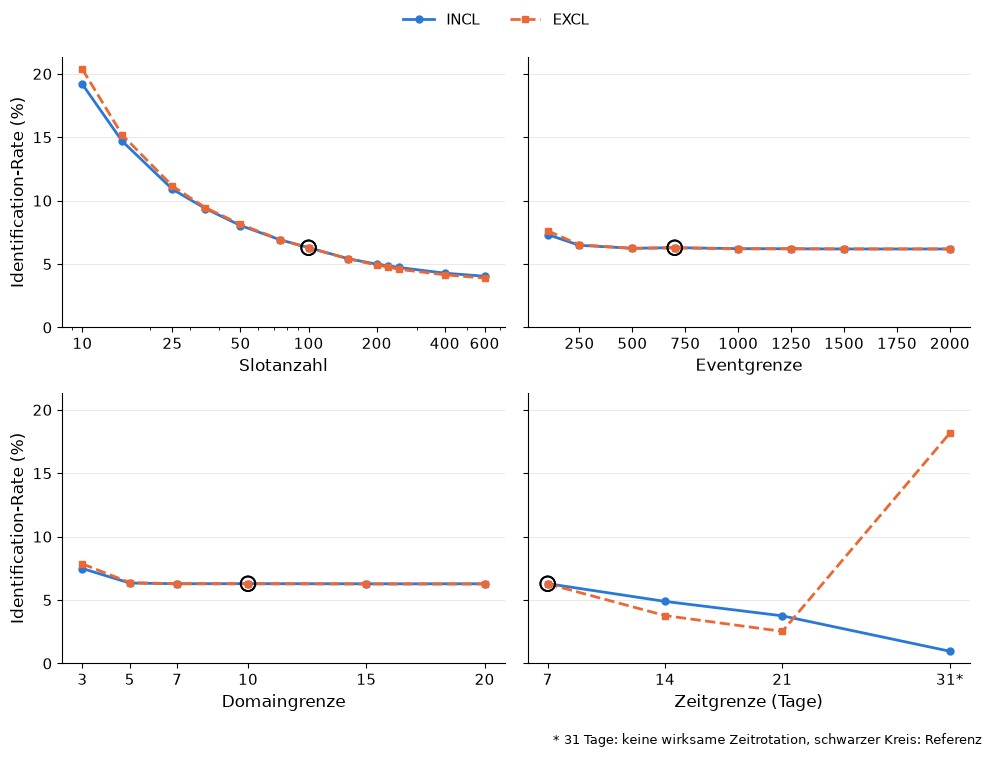

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7.5), sharey=True)

for ax, (name, param) in zip(axes.flat, series.items()):
    data = get_series(param)
    ax.plot(data.index, data["INCL (%)"], color=incl_color, linewidth=2, marker="o", markersize=5, label="INCL")
    ax.plot(data.index, data["EXCL (%)"], color=excl_color, linewidth=2, linestyle="--", marker="s", markersize=5, label="EXCL")
    # Referenzpunkt als schwarzer Kreis
    r = data.loc[ref[param]]
    ax.scatter([ref[param]] * 2, [r["INCL (%)"], r["EXCL (%)"]], s=110, facecolors="none", edgecolors="black", linewidths=1.3, zorder=3)
    param_axis(ax, param)
    ax.set_xlabel(name)
    style(ax)

for ax in axes[:, 0]:
    ax.set_ylabel("Identification-Rate (%)")
axes[0, 0].set_ylim(bottom=0)
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.tight_layout(rect=(0, 0.03, 1, 0.95))
fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False)
# info
fig.text(0.99, 0.01, "* 31 Tage: keine wirksame Zeitrotation, schwarzer Kreis: Referenz", ha="right", fontsize=9)
plt.show()

### 1.1 Rotationen pro Nutzer

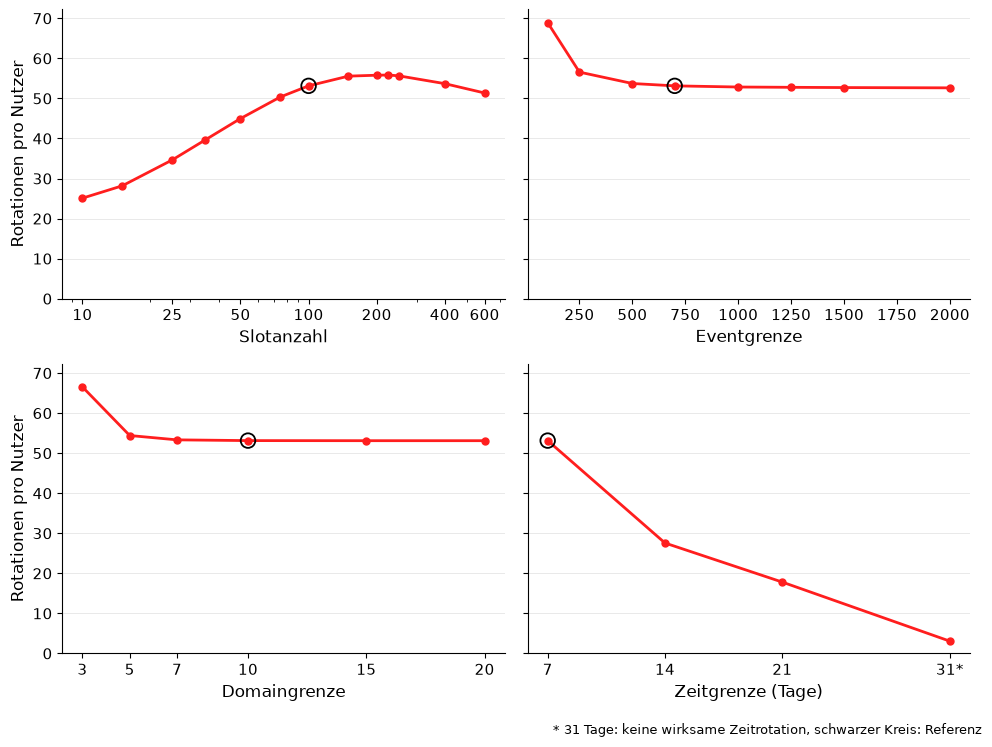

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7.5), sharey=True)

for ax, (name, param) in zip(axes.flat, series.items()):
    data = get_series(param)
    ax.plot(data.index, data["Rotationen pro Nutzer"], color="#FF1E1E", linewidth=2, marker="o", markersize=5)
    ax.scatter([ref[param]], [data.loc[ref[param], "Rotationen pro Nutzer"]],
               s=110, facecolors="none", edgecolors="black", linewidths=1.3, zorder=3)
    param_axis(ax, param)
    ax.set_xlabel(name)
    style(ax)

for ax in axes[:, 0]:
    ax.set_ylabel("Rotationen pro Nutzer")
axes[0, 0].set_ylim(bottom=0)
fig.tight_layout(rect=(0, 0.03, 1, 1))
# infooo
fig.text(0.99, 0.01, "* 31 Tage: keine wirksame Zeitrotation, schwarzer Kreis: Referenz", ha="right", fontsize=9)
plt.show()

### 1.2 Werte für den Text

In [ ]:
main_cols = ["INCL (%)", "EXCL (%)", "Rotationen pro Nutzer", "Median (Tage)", "Segmente mit mind. zwei Domains (%)"]
# alle werte in den main cols für alle parameter
for name, param in series.items():
    print(name)
    display(get_series(param)[main_cols].round(2))

r = get_series("Max_Days").loc[31]
# wie viele segmente gehen in die excl rechnung mit ein
print("31 Tage: EXCL-Segmente", int(r["Excl_Valid_Segments"]), "von", int(r["Incl_Valid_Segments"]), f"({r['Excl_Valid_Segments'] / r['Incl_Valid_Segments'] * 100:.2f} %)")

# höchste Ähnlichkeit zu einem eigenen bzw. fremden Segment entlang der slotreihe
get_series("Slots")[["Incl_Avg_Max_Cosine_Own", "Incl_Avg_Max_Cosine_Other"]].round(3)

Slotanzahl


,INCL (%),EXCL (%),Rotationen pro Nutzer,Median (Tage),Segmente mit mind. zwei Domains (%)
Slots,,,,,
10,19.17,20.36,25.10,7.01,88.23
15,14.69,15.18,28.18,7.16,82.60
25,10.90,11.15,34.67,7.56,73.95
35,9.37,9.44,39.68,7.78,67.23
50,8.04,8.14,44.98,7.94,59.29
75,6.91,6.92,50.37,8.06,49.78
100,6.29,6.27,53.14,8.20,42.90
150,5.42,5.41,55.57,8.60,33.67
200,5.00,4.92,55.80,8.81,27.57


Eventgrenze


,INCL (%),EXCL (%),Rotationen pro Nutzer,Median (Tage),Segmente mit mind. zwei Domains (%)
Max_Events,,,,,
100,7.32,7.62,68.92,7.35,42.37
250,6.48,6.52,56.57,8.03,42.98
500,6.24,6.24,53.73,8.17,42.94
700,6.29,6.27,53.14,8.20,42.90
1000,6.22,6.20,52.85,8.23,42.92
1250,6.20,6.20,52.78,8.24,42.87
1500,6.19,6.19,52.72,8.25,42.89
2000,6.19,6.19,52.65,8.26,42.90


Domaingrenze


,INCL (%),EXCL (%),Rotationen pro Nutzer,Median (Tage),Segmente mit mind. zwei Domains (%)
Max_Domains,,,,,
3,7.48,7.85,66.56,7.26,47.78
5,6.34,6.38,54.41,8.10,43.60
7,6.29,6.28,53.33,8.18,43.01
10,6.29,6.27,53.14,8.20,42.90
15,6.28,6.26,53.12,8.20,42.89
20,6.28,6.26,53.12,8.20,42.89


Zeitgrenze (Tage)


,INCL (%),EXCL (%),Rotationen pro Nutzer,Median (Tage),Segmente mit mind. zwei Domains (%)
Max_Days,,,,,
7,6.29,6.27,53.14,8.20,42.90
14,4.89,3.78,27.57,15.11,49.08
21,3.75,2.53,17.81,21.91,51.52
31,0.96,18.17,3.06,12.94,52.65


31 Tage: EXCL-Segmente 6572 von 112488 (5.84 %)


,Incl_Avg_Max_Cosine_Own,Incl_Avg_Max_Cosine_Other
Slots,,
10,0.400,0.606
15,0.409,0.660
25,0.425,0.719
35,0.436,0.752
50,0.445,0.780
75,0.450,0.805
100,0.452,0.820
150,0.452,0.837
200,0.452,0.846


### 1.3 Ausgang der Verkettungsversuche
Prüft wie oft einer dieser Fällte auftritt: verkettet, Gleichstand, ein fremdes Segment ist ähnlicher oder es gibt keine gemeinsame Domain mit einem eigenen Segment.

Die Werte stehen in `verkettungs_ranking.csv`, wenn `verkettung.py` mit der erweiterten `linkage_metrics` gelaufen ist. Fehlen die Spalten, wird die Verkettung hier auf den Rohdaten der Referenz-Slotreihe nachgerechnet. Das dauert je nach Rechner über eine Stunde.

In [ ]:
ref_rows = ranking[(ranking["Max_Domains"] == ref["Max_Domains"]) & (ranking["Max_Events"] == ref["Max_Events"]) & (ranking["Max_Days"] == ref["Max_Days"])].set_index("Slots")

# Kennzahlen kommen aus verkettung.py
if "Incl_Tie_Share" not in ranking.columns:
    raise ValueError(f"{ranking_file.name} enthält die neuen Kennzahlen nicht")
extra = ref_rows.loc[slot_list]

# die vier Fälle ergeben zusammen 100 %, "fremd ähnlicher" ist der Rest
outcome = pd.DataFrame({
    "Verkettet": extra["Incl_Identification_Rate"],
    "Gleichstand": extra["Incl_Tie_Share"],
    "Keine gemeinsame Domain": extra["Incl_No_Own_Share"],
}) * 100
outcome["Fremdes Segment ähnlicher"] = 100 - outcome.sum(axis=1)
outcome = outcome[["Verkettet", "Gleichstand", "Fremdes Segment ähnlicher", "Keine gemeinsame Domain"]]

summary = pd.DataFrame({
    "INCL (%)": extra["Incl_Identification_Rate"] * 100,
    "Zufalls-Baseline (%)": extra["Incl_Random_Baseline"] * 100,
    "Faktor ggü. Zufall": extra["Incl_Identification_Rate"] / extra["Incl_Random_Baseline"],
    "Gleichstand (%)": extra["Incl_Tie_Share"] * 100,
    "Gleichstände mit einer Domain (%)": extra["Incl_Tie_Single_Domain_Share"] * 100,
    "Nutzer mit mind. einer Verkettung (%)": extra["Incl_Users_Linked_Share"] * 100,
    "Nach Aufrufen gewichtet (%)": extra["Incl_Visit_Weighted_Rate"] * 100,
})
summary.round(3)

ValueError: verkettungs_ranking.csv enthält die neuen Kennzahlen nicht, verkettung.py mit der erweiterten linkage_metrics neu laufen lassen.

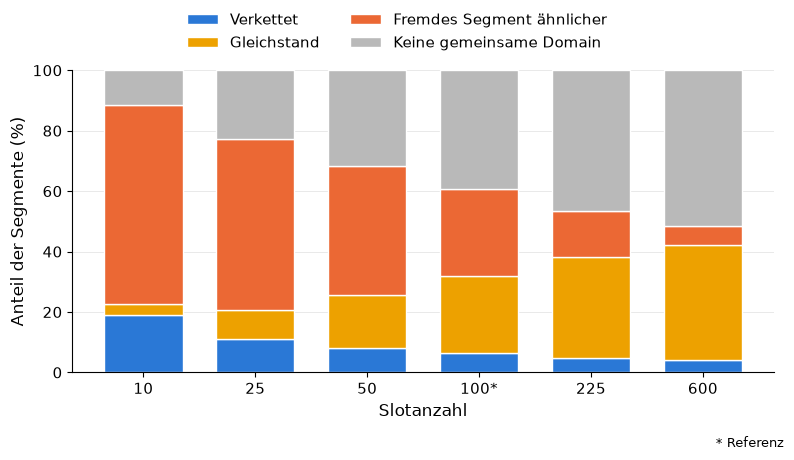

,Verkettet,Gleichstand,Fremdes Segment ähnlicher,Keine gemeinsame Domain
Slots,,,,
10,19.17,3.40,65.99,11.44
25,10.90,9.86,56.50,22.74
50,8.04,17.46,42.88,31.62
100,6.29,25.56,28.70,39.44
225,4.86,33.34,15.20,46.59
600,4.04,38.28,6.11,51.57


In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.5))
x = range(len(outcome))
bottom = np.zeros(len(outcome))
for col, color in zip(outcome.columns, [colors[0], colors[3], colors[1], "#b9b9b9"]):
    ax.bar(x, outcome[col], bottom=bottom, color=color, width=0.7, edgecolor="white", linewidth=1, label=col)
    bottom += outcome[col].values
ax.set_xticks(x)
ax.set_xticklabels([f"{s}*" if s == ref["Slots"] else str(s) for s in outcome.index])
ax.set_xlabel("Slotanzahl")
ax.set_ylabel("Anteil der Segmente (%)")
ax.set_ylim(0, 100)
style(ax)
handles, labels = ax.get_legend_handles_labels()
fig.tight_layout(rect=(0, 0.03, 1, 0.9))
fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False)
fig.text(0.99, 0.01, "* Referenz", ha="right", fontsize=9)
plt.show()
outcome.round(2)

### 1.4 Niedrige Domain-Grenzen

In [ ]:
low = df[
    df["Slots"].isin([25, 50, 100])
    & df["Max_Domains"].isin([3, 5])
    & df["Max_Events"].isin([25, 100, 250])
    & (df["Max_Days"] == ref["Max_Days"])
]
low_table = low.pivot_table(index=["Slots", "Max_Events"], columns="Max_Domains", values=["INCL (%)", "EXCL (%)", "Rotationen pro Nutzer"])
low_table.round(2)

EXCL (%)        INCL (%)        Rotationen pro Nutzer        
Max_Domains             3      5        3      5                     3       5
Slots Max_Events                                                              
25    25            20.33  20.83    19.52  19.84                168.17  136.93
      100           20.25  17.84    18.91  16.50                100.44   61.33
      250           19.77  15.33    18.36  14.37                 89.23   49.11
50    25            14.52  14.68    13.72  13.84                159.96  139.48
      100           13.38  11.37    12.36  10.70                 88.84   64.68
      250           12.52   9.80    11.59   9.35                 76.48   52.49
100   25            10.36  10.45     9.75   9.83                155.71  144.08
      100            8.69   7.67     8.19   7.34                 82.99   70.18
      250            8.03   6.72     7.70   6.60                 70.25   57.83

### 1.5 Anhang Tabelle: vollständige Parameterreihen

In [10]:
appendix_cols = main_cols + list(reasons.values())
for name, param in series.items():
    print(name)
    display(get_series(param)[appendix_cols].round(2))

Slotanzahl


,INCL (%),EXCL (%),Rotationen pro Nutzer,Median (Tage),Segmente mit mind. zwei Domains (%),Rotation: Zeit,Rotation: Events,Rotation: Domains,Am Datenende abgelaufen,Am Datenende offen
Slots,,,,,,,,,,
10,19.17,20.36,25.10,7.01,88.23,42.77,3.50,30.57,6.18,16.97
15,14.69,15.18,28.18,7.16,82.60,55.03,3.25,14.75,8.23,18.74
25,10.90,11.15,34.67,7.56,73.95,62.12,2.57,4.66,10.99,19.66
35,9.37,9.44,39.68,7.78,67.23,62.82,2.10,1.99,13.15,19.94
50,8.04,8.14,44.98,7.94,59.29,61.64,1.77,0.78,15.68,20.13
75,6.91,6.92,50.37,8.06,49.78,59.10,1.52,0.19,18.95,20.23
100,6.29,6.27,53.14,8.20,42.90,56.47,1.34,0.06,21.80,20.33
150,5.42,5.41,55.57,8.60,33.67,52.28,1.19,0.01,26.03,20.50
200,5.00,4.92,55.80,8.81,27.57,48.83,1.11,0.00,29.49,20.57


Eventgrenze


,INCL (%),EXCL (%),Rotationen pro Nutzer,Median (Tage),Segmente mit mind. zwei Domains (%),Rotation: Zeit,Rotation: Events,Rotation: Domains,Am Datenende abgelaufen,Am Datenende offen
Max_Events,,,,,,,,,,
100,7.32,7.62,68.92,7.35,42.37,41.64,23.17,0.04,17.65,17.49
250,6.48,6.52,56.57,8.03,42.98,52.15,7.42,0.05,20.74,19.64
500,6.24,6.24,53.73,8.17,42.94,55.68,2.45,0.06,21.60,20.20
700,6.29,6.27,53.14,8.20,42.90,56.47,1.34,0.06,21.80,20.33
1000,6.22,6.20,52.85,8.23,42.92,57.00,0.67,0.06,21.88,20.38
1250,6.20,6.20,52.78,8.24,42.87,57.21,0.43,0.06,21.89,20.41
1500,6.19,6.19,52.72,8.25,42.89,57.33,0.29,0.06,21.92,20.41
2000,6.19,6.19,52.65,8.26,42.90,57.42,0.16,0.06,21.95,20.41


Domaingrenze


,INCL (%),EXCL (%),Rotationen pro Nutzer,Median (Tage),Segmente mit mind. zwei Domains (%),Rotation: Zeit,Rotation: Events,Rotation: Domains,Am Datenende abgelaufen,Am Datenende offen
Max_Domains,,,,,,,,,,
3,7.48,7.85,66.56,7.26,47.78,40.59,1.00,22.25,18.01,18.15
5,6.34,6.38,54.41,8.10,43.60,53.97,1.28,3.26,21.45,20.06
7,6.29,6.28,53.33,8.18,43.01,56.03,1.33,0.60,21.74,20.30
10,6.29,6.27,53.14,8.20,42.90,56.47,1.34,0.06,21.80,20.33
15,6.28,6.26,53.12,8.20,42.89,56.51,1.35,0.00,21.81,20.33
20,6.28,6.26,53.12,8.20,42.89,56.51,1.35,0.00,21.81,20.33


Zeitgrenze (Tage)


,INCL (%),EXCL (%),Rotationen pro Nutzer,Median (Tage),Segmente mit mind. zwei Domains (%),Rotation: Zeit,Rotation: Events,Rotation: Domains,Am Datenende abgelaufen,Am Datenende offen
Max_Days,,,,,,,,,,
7,6.29,6.27,53.14,8.20,42.90,56.47,1.34,0.06,21.80,20.33
14,4.89,3.78,27.57,15.11,49.08,36.47,2.70,0.29,22.92,37.63
21,3.75,2.53,17.81,21.91,51.52,24.88,3.58,0.53,22.48,48.53
31,0.96,18.17,3.06,12.94,52.65,0.00,5.02,0.82,0.00,94.16


## 2. Abschlussgründe

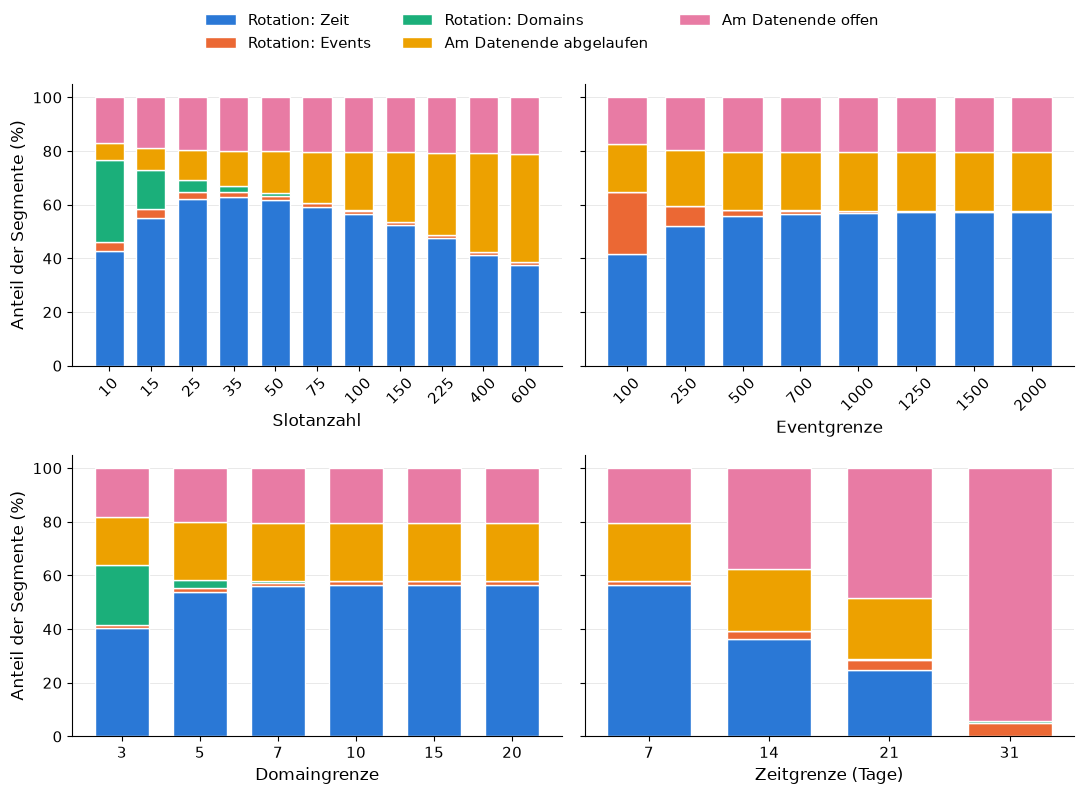

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharey=True)

for ax, (name, param) in zip(axes.flat, series.items()):
    data = get_series(param)
    if param == "Slots":
        data = data.loc[data.index.isin(bar_slots)]
    x = range(len(data))
    bottom = [0] * len(data)
    for reason, color in zip(reasons.values(), colors):
        ax.bar(x, data[reason], bottom=bottom, color=color, width=0.7,
               edgecolor="white", linewidth=1, label=reason)
        bottom = [b + v for b, v in zip(bottom, data[reason])]
    ax.set_xticks(x)
    ax.set_xticklabels(data.index, rotation=45 if len(data) > 7 else 0)
    ax.set_xlabel(name)
    style(ax)

for ax in axes[:, 0]:
    ax.set_ylabel("Anteil der Segmente (%)")
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.tight_layout(rect=(0, 0, 1, 0.92))
fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False)
plt.show()

### 2.1 Rotationen im Zeitverlauf
Abbildung 5.5. Alle Slots starten leer, deshalb rotieren nach sieben Tagen viele Pseudonyme gleichzeitig.

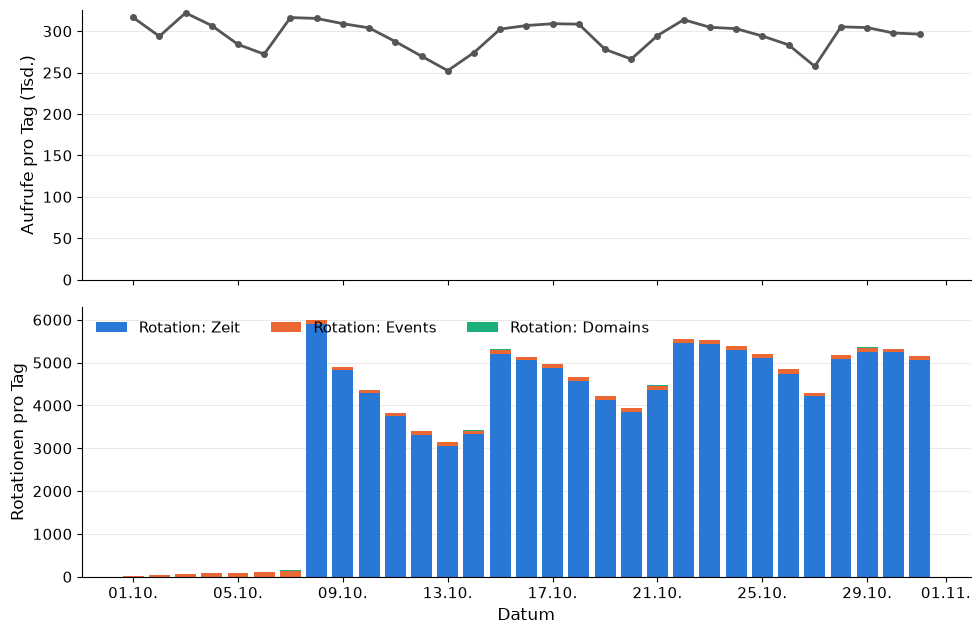

Rotationen in der ersten Woche: 577


,Aufrufe,Days,Events,Domains
used_at,,,,
2018-10-01,316553,0,17,0
2018-10-02,293837,0,47,0
2018-10-03,322107,0,76,0
2018-10-04,306741,0,77,4
2018-10-05,284014,0,93,4
2018-10-06,272259,0,107,3
2018-10-07,316454,0,141,8
2018-10-08,315421,5892,93,11
2018-10-09,309095,4819,71,3


In [ ]:
events = pd.read_csv(segments_dir / f"{ref_name}_events.csv", usecols=["used_at"], parse_dates=["used_at"])
segments = pd.read_csv(segments_dir / f"{ref_name}_segments.csv",
                       usecols=["end_time", "trigger", "trigger_detail"], parse_dates=["end_time"])

# Aufrufe pro tag und rotationen pro tag je abschlussgrund
daily = events["used_at"].dt.floor("D").value_counts().sort_index().to_frame("Aufrufe")
rot = segments[segments["trigger"] == "rotation_threshold"]
for detail in ["Days", "Events", "Domains"]:
    counts = rot.loc[rot["trigger_detail"] == detail, "end_time"].dt.floor("D").value_counts()
    daily[detail] = counts.reindex(daily.index, fill_value=0)

fig, (top, bottom) = plt.subplots(2, 1, figsize=(10, 6.5), sharex=True)

top.plot(daily.index, daily["Aufrufe"] / 1000, color="#555555", linewidth=2, marker="o", markersize=4)
top.set_ylabel("Aufrufe pro Tag (Tsd.)")
top.set_ylim(bottom=0)

stack = 0
for detail, color in zip(["Days", "Events", "Domains"], colors):
    bottom.bar(daily.index, daily[detail], bottom=stack, width=0.8, color=color, label=reasons[detail])
    stack = stack + daily[detail]
bottom.set_ylabel("Rotationen pro Tag")
bottom.legend(frameon=False, ncol=3, loc="upper left")
bottom.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m."))
bottom.set_xlabel("Datum")

for ax in (top, bottom):
    style(ax)
fig.tight_layout()
plt.show()

print("Rotationen in der ersten Woche:", int(daily.loc[:"2018-10-07", ["Days", "Events", "Domains"]].sum().sum()))
daily

## 3. Domains pro Pseudonym

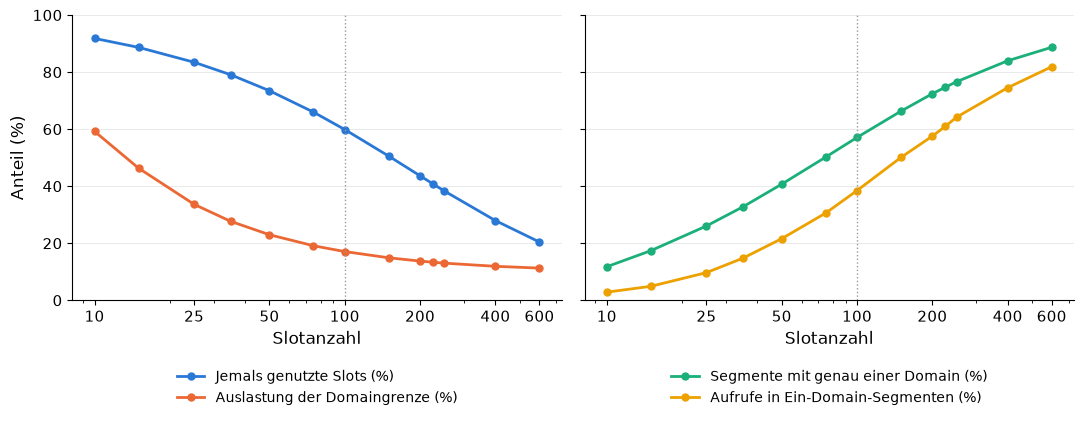

In [13]:
data = get_series("Slots")
fig, (left, right) = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)

for col, color in zip(["Jemals genutzte Slots (%)", "Auslastung der Domaingrenze (%)"], colors):
    left.plot(data.index, data[col], color=color, linewidth=2, marker="o", markersize=5, label=col)
for col, color in zip(["Segmente mit genau einer Domain (%)", "Aufrufe in Ein-Domain-Segmenten (%)"], colors[2:]):
    right.plot(data.index, data[col], color=color, linewidth=2, marker="o", markersize=5, label=col)

for ax in (left, right):
    slot_axis(ax)
    ax.axvline(ref["Slots"], color="#999999", linewidth=1, linestyle=":")
    ax.set_xlabel("Slotanzahl")
    ax.set_ylim(0, 100)
    style(ax)
    ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.2), fontsize=10)
left.set_ylabel("Anteil (%)")
fig.tight_layout()
plt.show()

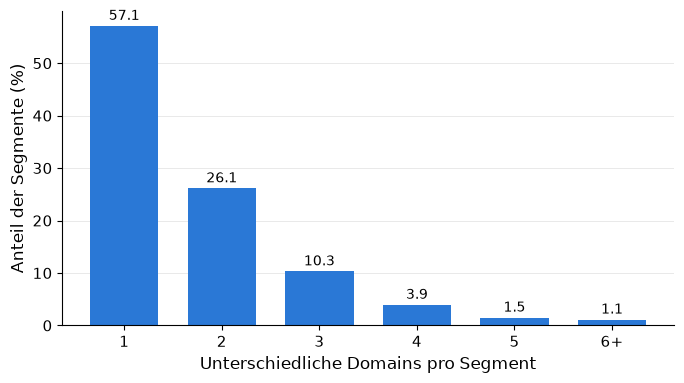

197258 nicht leere Segmente inkl. offener


In [14]:
domains = pd.read_csv(segments_dir / f"{ref_name}_segments.csv", usecols=["unique_domains"])["unique_domains"]

# alles ab 6 Domains in einen Balken
counts = domains.clip(upper=6).value_counts(normalize=True).reindex(range(1, 7), fill_value=0) * 100
labels = [str(i) for i in range(1, 6)] + ["6+"]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, counts, color=colors[0], width=0.7)
ax.bar_label(bars, labels=[f"{v:.1f}" for v in counts], padding=2, fontsize=10)
ax.set_xlabel("Unterschiedliche Domains pro Segment")
ax.set_ylabel("Anteil der Segmente (%)")
style(ax)
fig.tight_layout()
plt.show()
print(len(domains), "nicht leere Segmente inkl. offener")

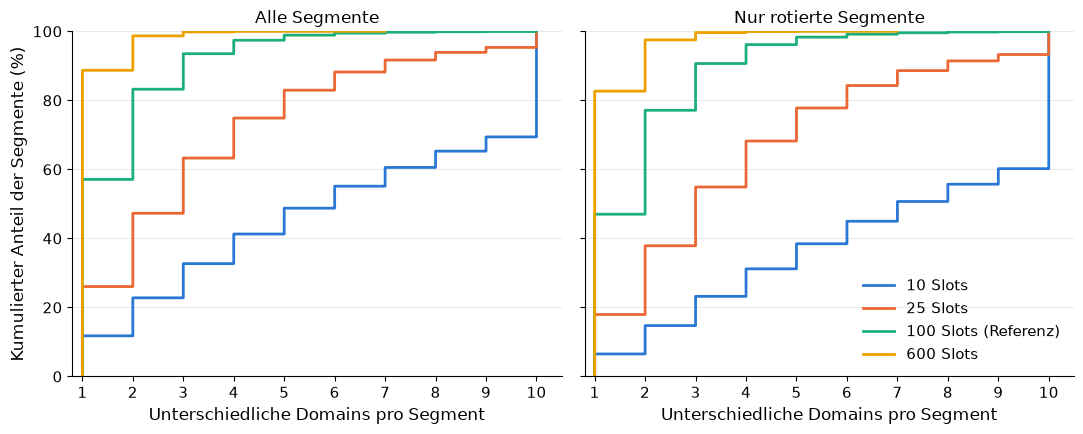

In [ ]:
def ecdf(ax, values, **kwargs):
    # Verteilungsfunktion als treppenkurve
    x = np.sort(values)
    y = np.arange(1, len(x) + 1) / len(x) * 100
    ax.step(x, y, where="post", linewidth=2, **kwargs)


ecdf_slots = [10, 25, 100, 600]
fig, (left, right) = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)

for slots, color in zip(ecdf_slots, colors):
    seg = pd.read_csv(segments_dir / f"{raw_name(slots)}_segments.csv", usecols=["trigger", "unique_domains"])
    label = f"{slots} Slots" + (" (Referenz)" if slots == ref["Slots"] else "")
    ecdf(left, seg["unique_domains"], color=color, label=label)
    ecdf(right, seg.loc[seg["trigger"] == "rotation_threshold", "unique_domains"], color=color, label=label)

left.set_title("Alle Segmente")
right.set_title("Nur rotierte Segmente")
for ax in (left, right):
    ax.set_xticks(range(1, 11))
    ax.set_xlim(0.8, 10.5)
    ax.set_ylim(0, 100)
    ax.set_xlabel("Unterschiedliche Domains pro Segment")
    style(ax)
left.set_ylabel("Kumulierter Anteil der Segmente (%)")
right.legend(frameon=False, loc="lower right")
fig.tight_layout()
plt.show()

### 3.1 Kaltstart
Zeit, bis ein Segment seine zweite Domain sieht, nur für Segmente, die überhaupt eine zweite erreichen

In [ ]:
def hours_to_second_domain(slots):
    keys_ev = ["panelist_id", "slot_id", "segment_id"]
    ev = pd.read_csv(segments_dir / f"{raw_name(slots)}_events.csv", parse_dates=["used_at"])
    ev = ev.sort_values(["panelist_id", "used_at"], kind="stable")

    # erster aufruf jeder domain im segment nummeriert
    first = ev.drop_duplicates(keys_ev + ["domain"]).copy()
    first["n"] = first.groupby(keys_ev).cumcount() + 1

    # Abstand zwischen segmentstart und erstem aufruf der zweiten domain
    start = ev.groupby(keys_ev)["used_at"].min()
    second = first[first["n"] == 2].set_index(keys_ev)["used_at"]
    hours = (second - start.reindex(second.index)).dt.total_seconds() / 3600
    return hours.median()

cold = get_series("Slots").loc[slot_list, ["Segmente mit mind. zwei Domains (%)"]].round(2)
cold["Median Stunden bis 2. Domain"] = [round(hours_to_second_domain(n), 2) for n in slot_list]
cold

,Segmente mit mind. zwei Domains (%),Median Stunden bis 2. Domain
Slots,,
10,88.23,5.01
25,73.95,23.75
50,59.29,40.19
100,42.90,49.61
225,25.33,62.13
600,11.29,69.23


## 4. Zielkonflikt

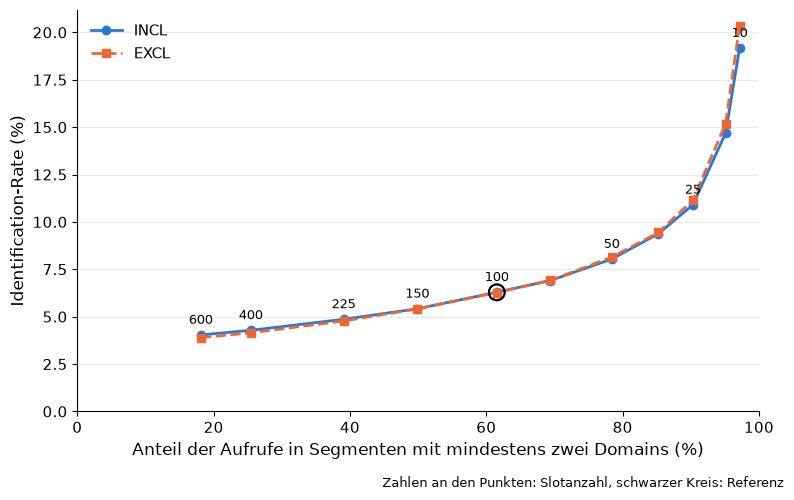

,INCL (%),EXCL (%),Aufrufe in Segmenten mit mind. zwei Domains (%),Segmente mit mind. zwei Domains (%)
Slots,,,,
10,19.17,20.36,97.15,88.23
15,14.69,15.18,95.10,82.60
25,10.90,11.15,90.30,73.95
35,9.37,9.44,85.24,67.23
50,8.04,8.14,78.40,59.29
75,6.91,6.92,69.40,49.78
100,6.29,6.27,61.54,42.90
150,5.42,5.41,49.88,33.67
225,4.86,4.77,39.06,25.33


In [17]:
data = get_series("Slots")
data = data.loc[data.index.isin(bar_slots)]
x = data["Aufrufe in Segmenten mit mind. zwei Domains (%)"]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x, data["INCL (%)"], color=incl_color, linewidth=2, marker="o", markersize=6, label="INCL")
ax.plot(x, data["EXCL (%)"], color=excl_color, linewidth=2, linestyle="--", marker="s", markersize=6, label="EXCL")
r = data.loc[ref["Slots"]]
ax.scatter([r["Aufrufe in Segmenten mit mind. zwei Domains (%)"]] * 2, [r["INCL (%)"], r["EXCL (%)"]],
           s=130, facecolors="none", edgecolors="black", linewidths=1.3, zorder=3)
for slots, xv, yv in zip(data.index, x, data["INCL (%)"]):
    if slots in (15, 35, 75):  # liegen zu nah an den Nachbarn
        continue
    ax.annotate(str(slots), (xv, yv), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9)
ax.set_xlabel("Anteil der Aufrufe in Segmenten mit mindestens zwei Domains (%)")
ax.set_ylabel("Identification-Rate (%)")
ax.set_xlim(0, 100)
ax.set_ylim(bottom=0)
style(ax)
ax.legend(frameon=False, loc="upper left")
fig.text(0.99, 0.01, "Zahlen an den Punkten: Slotanzahl, schwarzer Kreis: Referenz", ha="right", fontsize=9)
fig.tight_layout(rect=(0, 0.03, 1, 1))
plt.show()

data[["INCL (%)", "EXCL (%)", "Aufrufe in Segmenten mit mind. zwei Domains (%)", "Segmente mit mind. zwei Domains (%)"]].round(2)

## 5. Ohne wirksame Zeitrotation (31 Tage)
Nur Domain- und Eventgrenze können eine Rotation auslösen

232 Konfigurationen


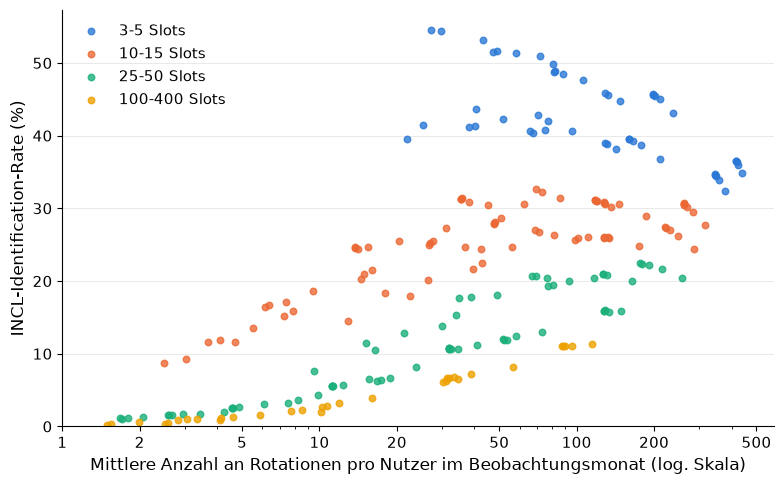

In [18]:
no_time = df[df["Max_Days"] == 31].copy()
print(len(no_time), "Konfigurationen")

fig, ax = plt.subplots(figsize=(8, 5))
no_time["Slotgruppe"] = pd.cut(no_time["Slots"], [0, 5, 15, 50, 600], labels=["3-5", "10-15", "25-50", "100-400"])
for (group, d), color in zip(no_time.groupby("Slotgruppe", observed=True), colors):
    ax.scatter(d["Rotationen pro Nutzer"], d["INCL (%)"], color=color, s=22, alpha=0.8, label=f"{group} Slots")
ax.set_xscale("log")
ax.set_xticks([1, 2, 5, 10, 20, 50, 100, 200, 500])
ax.set_xticklabels(["1", "2", "5", "10", "20", "50", "100", "200", "500"])
ax.set_xlabel("Mittlere Anzahl an Rotationen pro Nutzer im Beobachtungsmonat (log. Skala)")
ax.set_ylabel("INCL-Identification-Rate (%)")
ax.set_ylim(bottom=0)
style(ax)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

In [ ]:
# Slots x Domaingrenze bei 500 Events
grid = no_time[(no_time["Max_Events"] == 500) & no_time["Max_Domains"].isin([2, 3, 5, 7, 10])]
print("INCL (%), 500 Events, 31 Tage")
display(grid.pivot_table(index="Slots", columns="Max_Domains", values="INCL (%)").round(1))
print("Rotationen pro Nutzer, 500 Events, 31 Tage")
display(grid.pivot_table(index="Slots", columns="Max_Domains", values="Rotationen pro Nutzer").round(1))

print("Slotanzahl bei 5 Domains, 31 Tage")
display(no_time[no_time["Max_Domains"] == 5].pivot_table(index="Slots", columns="Max_Events", values="INCL (%)").round(2))

# gleiche konfiguration mit und ohne zeitrotation
pairs = df[df["Max_Days"].isin([ref["Max_Days"], 31])].pivot_table(
    index=["Slots", "Max_Domains", "Max_Events"], columns="Max_Days", values=["INCL (%)", "Rotationen pro Nutzer"]
).dropna()
print(ref["Max_Days"], "vs. 31 Tage")
pairs.round(2)

INCL (%), 500 Events, 31 Tage


Max_Domains,2,3,5,7,10
Slots,,,,,
3,36.6,45.6,48.8,51.6,54.6
5,34.7,39.6,40.7,41.2,39.5
10,30.7,31.1,28.1,25.6,21.5
15,27.4,25.6,21.7,18.0,14.5
25,22.5,19.4,13.8,10.5,7.7
50,16.0,11.9,6.7,4.3,3.1
100,11.0,6.8,2.6,1.6,1.3


Rotationen pro Nutzer, 500 Events, 31 Tage


Max_Domains,2,3,5,7,10
Slots,,,,,
3,416.5,197.4,81.8,47.4,27.2
5,343.6,159.6,66.0,38.1,21.9
10,260.9,118.7,48.2,27.7,16.0
15,220.4,98.8,39.6,22.5,12.9
25,176.6,77.5,29.9,16.5,9.5
50,128.9,53.4,18.8,9.9,6.1
100,90.4,33.4,10.2,5.9,4.6


Slotanzahl bei 5 Domains, 31 Tage


Max_Events,25,50,100,250,500,750,1000
Slots,,,,,,,
3,44.75,47.62,48.47,48.85,48.81,NaN,NaN
5,38.17,40.70,40.80,40.40,40.66,NaN,NaN
10,30.20,31.38,30.65,28.63,28.13,27.89,28.03
15,25.88,26.31,24.62,22.47,21.68,NaN,NaN
25,20.77,20.37,18.06,15.35,13.81,NaN,NaN
50,NaN,NaN,11.14,8.16,6.73,6.40,6.22
100,NaN,NaN,6.48,3.86,2.62,2.26,2.12


7 vs. 31 Tage


INCL (%)        Rotationen pro Nutzer        
Max_Days                           7      31                    7       31
Slots Max_Domains Max_Events                                              
5     3           500           39.16  39.58                160.56  159.58
25    3           25            19.52  20.02                168.17  163.81
                  100           18.91  20.05                100.44   93.33
                  250           18.36  19.48                 89.23   80.64
      5           25            19.84  20.77                136.93  130.66
                  100           16.50  18.06                 61.33   49.18
                  250           14.37  15.35                 49.11   33.97
50    3           100           12.36  13.04                 88.84   73.43
                  250           11.59  12.43                 76.48   57.97
      5           100           10.70  11.14                 64.68   41.08
                  250            9.35   8.16                 52.49   23.82
100   3           100            8.19   8.23                 82.99   56.55
                  250            7.70   7.16                 70.25   38.86
      5           100            7.34   6.48                 70.18   34.49
                  250            6.60   3.86                 57.83   15.97
      10          100            7.32   6.15                 68.92   30.26
                  250            6.48   2.87                 56.57   10.68
                  500            6.24   1.33                 53.73    4.60
                  700            6.29   0.96                 53.14    3.06
                  1000           6.22   0.65                 52.85    1.99
225   10          700            4.86   0.43                 55.85    2.58
                  1000           4.88   0.30                 55.47    1.54
400   10          700            4.28   0.29                 53.70    2.52
                  1000           4.28   0.21                 53.34    1.49

## 6. Vergleich
Nur Konfigurationen mit Zeitrotation

In [25]:
pareto = df[df["Max_Days"] == 7].reset_index(drop=True)
crit = np.column_stack([
    pareto["INCL (%)"],
    pareto["EXCL (%)"],
    #kleiner = besser
    -pareto["Segmente mit mind. zwei Domains (%)"],
])

def dominated_by(i):
    # Konfigurationen, die in allen kriterien mindestens gleich und in einem echt besser sind
    better_or_equal = np.all(crit <= crit[i], axis=1)
    strictly_better = np.any(crit < crit[i], axis=1)
    return np.where(better_or_equal & strictly_better)[0]

pareto["Pareto"] = [len(dominated_by(i)) == 0 for i in range(len(pareto))]
show = keys + ["INCL (%)", "EXCL (%)", "Segmente mit mind. zwei Domains (%)"]

ref_idx = pareto.index[(pareto[keys] == pd.Series(ref)).all(axis=1)][0]
print("nicht dominiert:", pareto["Pareto"].sum(), "von", len(pareto))
print("Referenz nicht dominiert:", pareto.loc[ref_idx, "Pareto"])
print("Referenz wird dominiert von:")
display(pareto.loc[dominated_by(ref_idx), show].round(2))

pareto[pareto["Pareto"]].sort_values("INCL (%)")[show].round(2)

nicht dominiert: 33 von 66
Referenz nicht dominiert: False
Referenz wird dominiert von:


,Slots,Max_Domains,Max_Events,Max_Days,INCL (%),EXCL (%),Segmente mit mind. zwei Domains (%)
0,100,10,1000,7,6.22,6.20,42.92
4,100,10,2000,7,6.19,6.19,42.90
6,100,10,500,7,6.24,6.24,42.94


,Slots,Max_Domains,Max_Events,Max_Days,INCL (%),EXCL (%),Segmente mit mind. zwei Domains (%)
64,600,10,700,7,4.04,3.89,11.29
51,400,10,1000,7,4.28,4.14,16.02
52,400,10,700,7,4.28,4.15,16.03
39,250,15,1000,7,4.70,4.59,23.36
37,250,10,1000,7,4.70,4.59,23.36
38,250,10,700,7,4.73,4.59,23.37
40,250,15,700,7,4.73,4.59,23.37
33,225,15,700,7,4.86,4.77,25.33
31,225,10,700,7,4.86,4.77,25.33
34,225,30,700,7,4.86,4.77,25.33
